In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

%matplotlib inline

In [2]:
# Load training data with all timestamp columns
timestamp_cols = ['timestamp', 'meal_timestamp', 'finger_stick_timestamp', 'bolus_timestamp', 
                  'exercise_timestamp', 'hypo_timestamp', 'stress_timestamp']

train_df = pd.read_csv('../data/processed/train_data.csv', parse_dates=timestamp_cols)
test_df = pd.read_csv('../data/processed/test_data.csv', parse_dates=timestamp_cols)

print(f"Training data: {train_df.shape}")
print(f"Testing data: {test_df.shape}")
print(f"\nTotal columns: {len(train_df.columns)}")
print(f"\nAll columns:")
for i, col in enumerate(train_df.columns, 1):
    print(f"  {i:2d}. {col}")

Training data: (69255, 24)
Testing data: (15970, 24)

Total columns: 24

All columns:
   1. patient_id
   2. timestamp
   3. glucose
   4. meal_timestamp
   5. meal_type
   6. carbs
   7. finger_stick_timestamp
   8. finger_stick_glucose
   9. basal_rate
  10. temp_basal_rate
  11. bolus_timestamp
  12. bolus_dose
  13. exercise_timestamp
  14. exercise_duration
  15. exercise_intensity
  16. hypo_timestamp
  17. hypo_event
  18. stress_timestamp
  19. stress_event
  20. heart_rate
  21. gsr
  22. skin_temp_f
  23. air_temp_f
  24. steps


In [3]:
# Display first few rows
train_df.head()

,patient_id,timestamp,glucose,meal_timestamp,meal_type,carbs,finger_stick_timestamp,finger_stick_glucose,basal_rate,temp_basal_rate,...,exercise_intensity,hypo_timestamp,hypo_event,stress_timestamp,stress_event,heart_rate,gsr,skin_temp_f,air_temp_f,steps
0,588,2021-08-30 11:53:00,116.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,84.0000,0.000067,92.30,91.22,0.0
1,588,2021-08-30 11:58:00,117.0,2021-08-30 11:59:00,Lunch,37.0,2021-08-30 12:00:02,114.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,111.0000,0.000066,91.40,89.15,35.0
2,588,2021-08-30 12:03:00,119.0,NaT,NaN,0.0,2021-08-30 12:03:57,114.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,80.0171,0.000000,91.40,88.70,0.0
3,588,2021-08-30 12:08:00,116.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,89.0000,0.000066,91.94,91.76,0.0
4,588,2021-08-30 12:13:00,111.0,NaT,NaN,0.0,NaT,0.0,1.2,1.2,...,0.0,NaT,0.0,NaT,0.0,83.0000,0.000067,93.20,92.66,0.0


In [4]:
# Data info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69255 entries, 0 to 69254
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   patient_id              69255 non-null  int64         
 1   timestamp               69255 non-null  datetime64[ns]
 2   glucose                 69255 non-null  float64       
 3   meal_timestamp          1009 non-null   datetime64[ns]
 4   meal_type               1009 non-null   object        
 5   carbs                   69255 non-null  float64       
 6   finger_stick_timestamp  1828 non-null   datetime64[ns]
 7   finger_stick_glucose    69255 non-null  float64       
 8   basal_rate              69255 non-null  float64       
 9   temp_basal_rate         69255 non-null  float64       
 10  bolus_timestamp         0 non-null      datetime64[ns]
 11  bolus_dose              69255 non-null  float64       
 12  exercise_timestamp      122 non-null    dateti

In [5]:
# Statistical summary
train_df.describe()

,patient_id,timestamp,glucose,meal_timestamp,carbs,finger_stick_timestamp,finger_stick_glucose,basal_rate,temp_basal_rate,bolus_timestamp,...,exercise_intensity,hypo_timestamp,hypo_event,stress_timestamp,stress_event,heart_rate,gsr,skin_temp_f,air_temp_f,steps
count,69255.000000,69255,69255.000000,1009,69255.000000,1828,69255.000000,69255.000000,69255.000000,0,...,69255.000000,70,69255.000000,4,69255.000000,69255.00000,69255.000000,69255.000000,69255.000000,69255.000000
mean,574.490838,2021-11-21 19:17:40.534545920,160.130012,2021-11-21 15:15:34.370663936,0.621601,2021-11-05 07:24:50.855580160,4.330460,0.957210,0.957210,NaT,...,0.008822,2021-11-17 14:59:21.428571392,0.001011,2021-10-19 21:50:00,0.000058,80.01710,0.652461,87.975048,84.660213,3.000476
min,559.000000,2021-08-30 11:53:00,40.000000,2021-08-30 11:59:00,0.000000,2021-08-30 12:00:02,0.000000,0.000000,0.000000,NaT,...,0.000000,2021-08-31 20:12:00,0.000000,2021-09-22 13:59:00,0.000000,45.00000,0.000000,56.480000,50.230000,0.000000
25%,563.000000,2021-10-08 03:54:30,114.000000,2021-10-07 23:30:00,0.000000,2021-09-24 13:49:00.249999872,0.000000,0.780000,0.780000,NaT,...,0.000000,2021-10-12 06:57:30,0.000000,2021-09-24 02:04:15,0.000000,68.00000,0.000061,86.000000,81.860000,0.000000
50%,575.000000,2021-12-10 00:28:00,153.000000,2021-12-09 06:26:00,0.000000,2021-10-20 15:30:57,0.000000,0.900000,0.900000,NaT,...,0.000000,2021-12-05 12:13:00,0.000000,2021-10-01 16:09:00,0.000000,80.00000,0.000094,87.975048,84.380000,0.000000
75%,588.000000,2021-12-26 09:37:30,200.000000,2021-12-24 23:27:00,0.000000,2021-12-20 13:51:33.249999872,0.000000,1.200000,1.200000,NaT,...,0.000000,2021-12-13 19:19:45,0.000000,2021-10-27 11:54:45,0.000000,89.00000,0.001021,89.960000,87.080000,0.000000
max,591.000000,2022-01-17 23:56:00,400.000000,2022-01-17 17:30:00,450.000000,2022-01-17 18:33:13,586.000000,1.600000,1.600000,NaT,...,9.000000,2022-01-13 03:50:00,1.000000,2021-12-22 17:03:00,1.000000,189.00000,28.460000,110.660000,119.480000,160.000000
std,11.822185,NaN,60.538026,NaN,6.611010,NaN,28.690597,0.229421,0.229421,NaN,...,0.215079,NaN,0.031777,NaN,0.007600,15.51948,2.750453,3.505662,4.463599,10.237795


In [6]:
# Check for missing values
missing = train_df.isnull().sum()
missing[missing > 0]

meal_timestamp            68246
meal_type                 68246
finger_stick_timestamp    67427
bolus_timestamp           69255
exercise_timestamp        69133
hypo_timestamp            69185
stress_timestamp          69251
dtype: int64

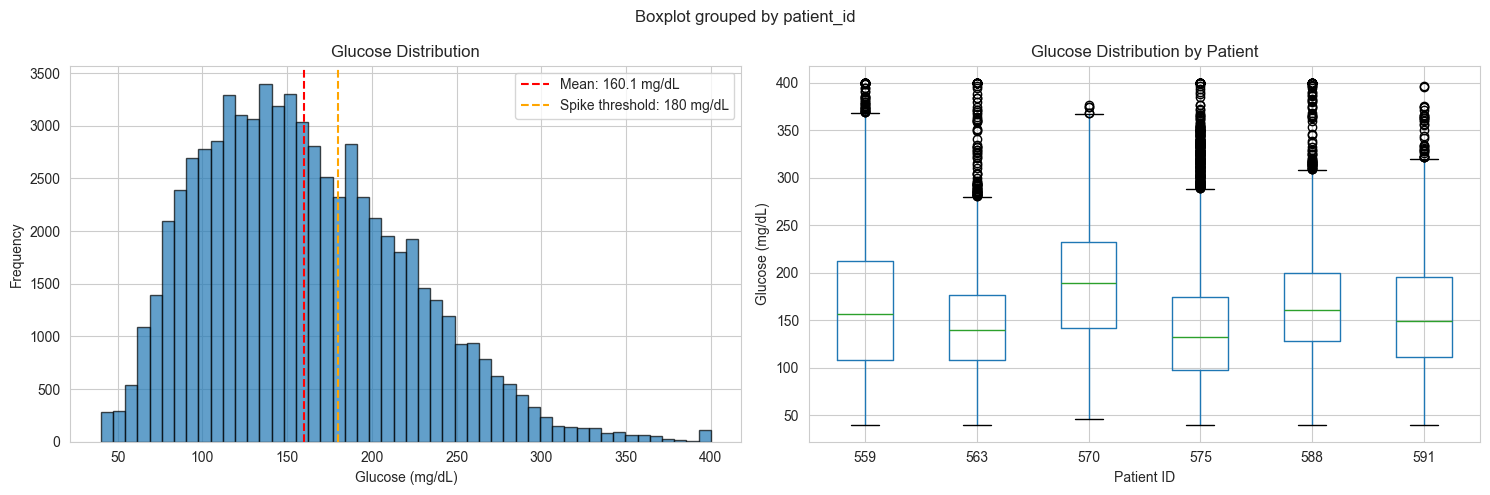

In [7]:
# Glucose distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(train_df['glucose'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(train_df['glucose'].mean(), color='red', linestyle='--', label=f'Mean: {train_df["glucose"].mean():.1f} mg/dL')
axes[0].axvline(180, color='orange', linestyle='--', label='Spike threshold: 180 mg/dL')
axes[0].set_xlabel('Glucose (mg/dL)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Glucose Distribution')
axes[0].legend()

# Box plot by patient
train_df.boxplot(column='glucose', by='patient_id', ax=axes[1])
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].set_title('Glucose Distribution by Patient')

plt.tight_layout()
plt.show()

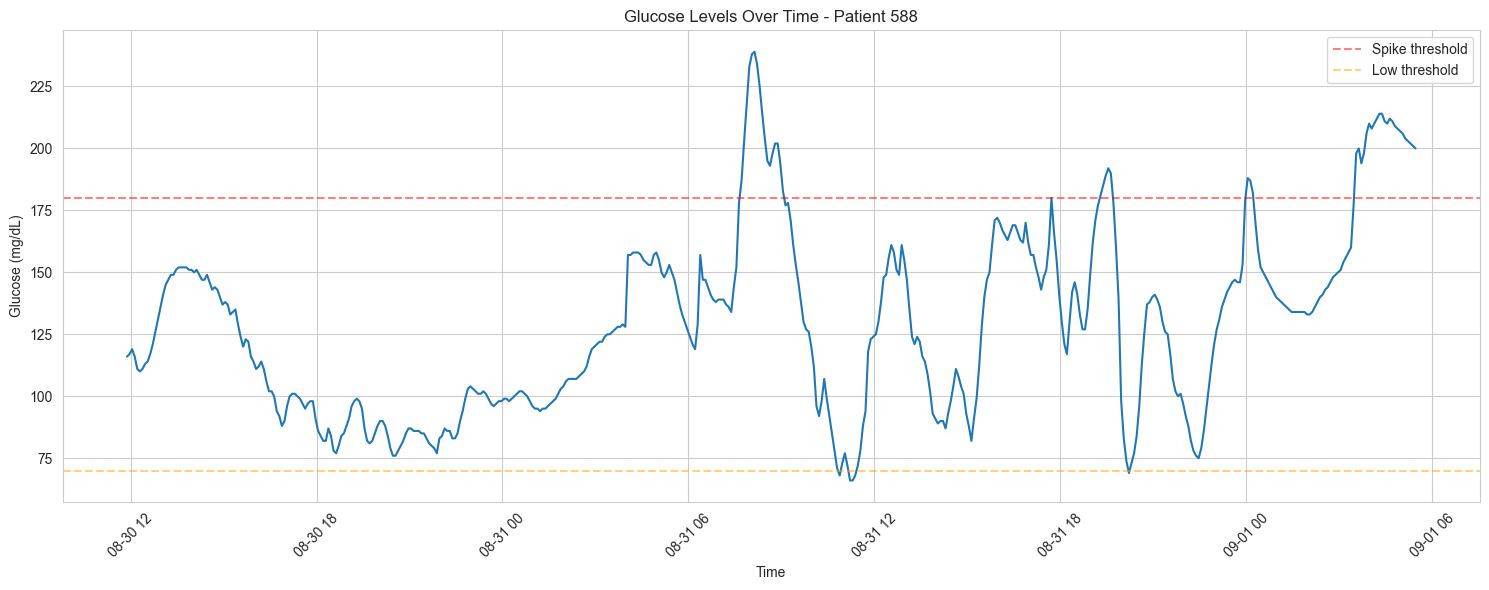

In [14]:
# Glucose over time for a single patient
patient_id = 588
patient_data = train_df[train_df['patient_id'] == patient_id].head(500)

plt.figure(figsize=(15, 6))
plt.plot(patient_data['timestamp'], patient_data['glucose'], linewidth=1.5)
plt.axhline(180, color='red', linestyle='--', alpha=0.5, label='Spike threshold')
plt.axhline(70, color='orange', linestyle='--', alpha=0.5, label='Low threshold')
plt.xlabel('Time')
plt.ylabel('Glucose (mg/dL)')
plt.title(f'Glucose Levels Over Time - Patient {patient_id}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total meal events: 1007
Average time difference between meal and glucose reading: 1.18 minutes
Max time difference: 2.00 minutes


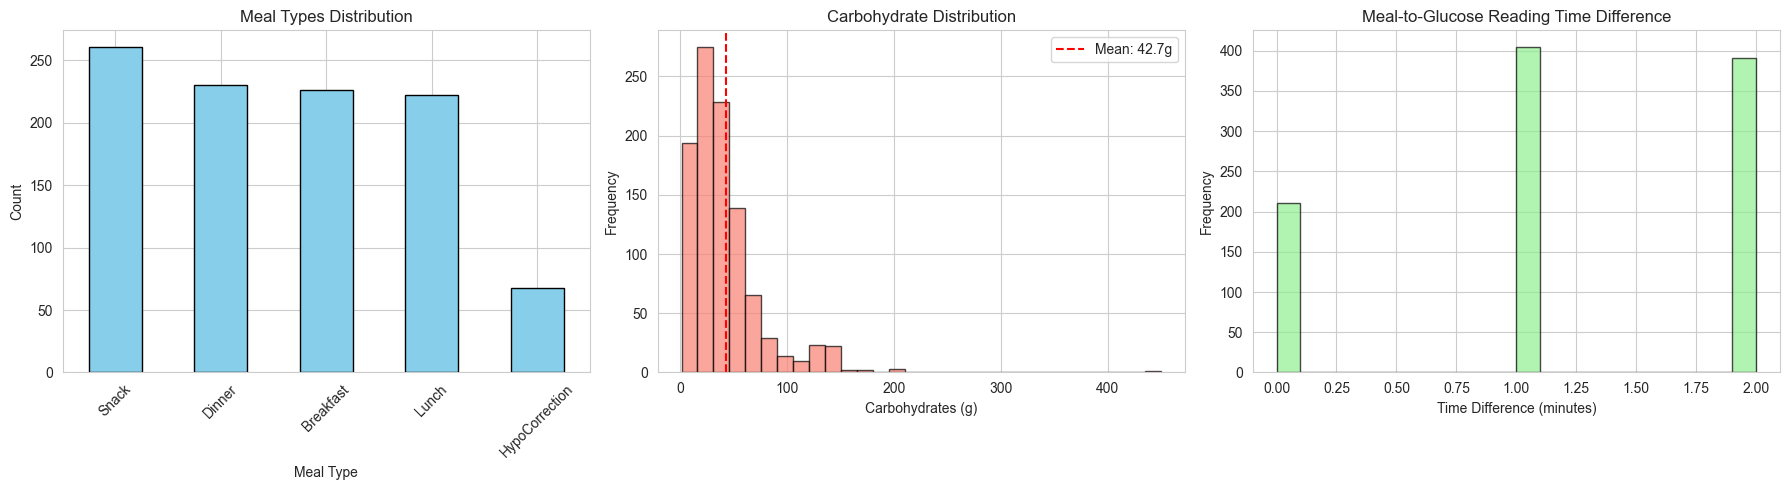


Meal Statistics:
  Average carbs per meal: 42.7g
  Median carbs: 35.0g
  Min/Max carbs: 1g / 450g


In [15]:

meal_events = train_df[train_df['carbs'] > 0].copy()

# Calculate time difference between glucose reading and actual meal time
meal_events['time_diff_minutes'] = (
    (meal_events['timestamp'] - meal_events['meal_timestamp']).dt.total_seconds() / 60
).abs()

print(f"Total meal events: {len(meal_events)}")
print(f"Average time difference between meal and glucose reading: {meal_events['time_diff_minutes'].mean():.2f} minutes")
print(f"Max time difference: {meal_events['time_diff_minutes'].max():.2f} minutes")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Meal types
meal_counts = meal_events['meal_type'].value_counts()
meal_counts.plot(kind='bar', ax=axes[0], edgecolor='black', color='skyblue')
axes[0].set_title('Meal Types Distribution')
axes[0].set_xlabel('Meal Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Carbs distribution
axes[1].hist(meal_events['carbs'], bins=30, edgecolor='black', alpha=0.7, color='salmon')
axes[1].axvline(meal_events['carbs'].mean(), color='red', linestyle='--', 
                label=f'Mean: {meal_events["carbs"].mean():.1f}g')
axes[1].set_xlabel('Carbohydrates (g)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Carbohydrate Distribution')
axes[1].legend()

# Time difference between meal and glucose reading
axes[2].hist(meal_events['time_diff_minutes'], bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_xlabel('Time Difference (minutes)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Meal-to-Glucose Reading Time Difference')

plt.tight_layout()
plt.show()

print(f"\nMeal Statistics:")
print(f"  Average carbs per meal: {meal_events['carbs'].mean():.1f}g")
print(f"  Median carbs: {meal_events['carbs'].median():.1f}g")
print(f"  Min/Max carbs: {meal_events['carbs'].min():.0f}g / {meal_events['carbs'].max():.0f}g")

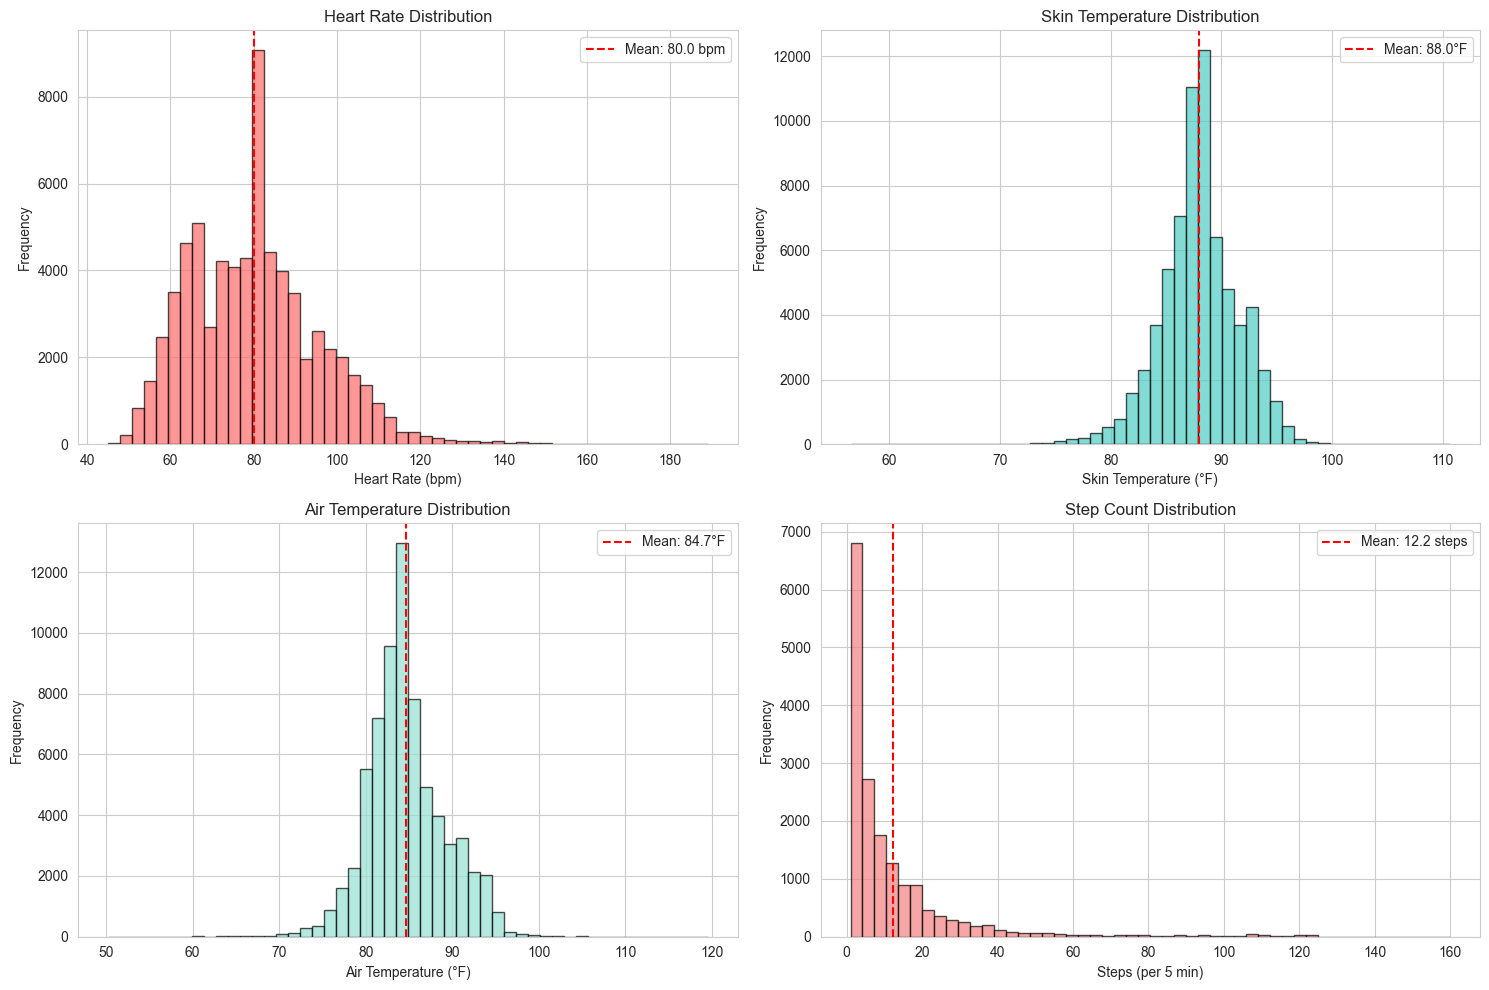

In [10]:
# Heart rate analysis
hr_data = train_df[train_df['heart_rate'] > 0]['heart_rate']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Heart rate
axes[0, 0].hist(hr_data, bins=50, edgecolor='black', alpha=0.7, color='#FF6B6B')
axes[0, 0].axvline(hr_data.mean(), color='red', linestyle='--', label=f'Mean: {hr_data.mean():.1f} bpm')
axes[0, 0].set_xlabel('Heart Rate (bpm)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Heart Rate Distribution')
axes[0, 0].legend()

# Skin temperature
skin_temp = train_df[train_df['skin_temp_f'] > 0]['skin_temp_f']
axes[0, 1].hist(skin_temp, bins=50, edgecolor='black', alpha=0.7, color='#4ECDC4')
axes[0, 1].axvline(skin_temp.mean(), color='red', linestyle='--', label=f'Mean: {skin_temp.mean():.1f}°F')
axes[0, 1].set_xlabel('Skin Temperature (°F)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Skin Temperature Distribution')
axes[0, 1].legend()

# Air temperature
air_temp = train_df[train_df['air_temp_f'] > 0]['air_temp_f']
axes[1, 0].hist(air_temp, bins=50, edgecolor='black', alpha=0.7, color='#95E1D3')
axes[1, 0].axvline(air_temp.mean(), color='red', linestyle='--', label=f'Mean: {air_temp.mean():.1f}°F')
axes[1, 0].set_xlabel('Air Temperature (°F)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Air Temperature Distribution')
axes[1, 0].legend()

# Steps
steps = train_df[train_df['steps'] > 0]['steps']
axes[1, 1].hist(steps, bins=50, edgecolor='black', alpha=0.7, color='#F38181')
axes[1, 1].axvline(steps.mean(), color='red', linestyle='--', label=f'Mean: {steps.mean():.1f} steps')
axes[1, 1].set_xlabel('Steps (per 5 min)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Step Count Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

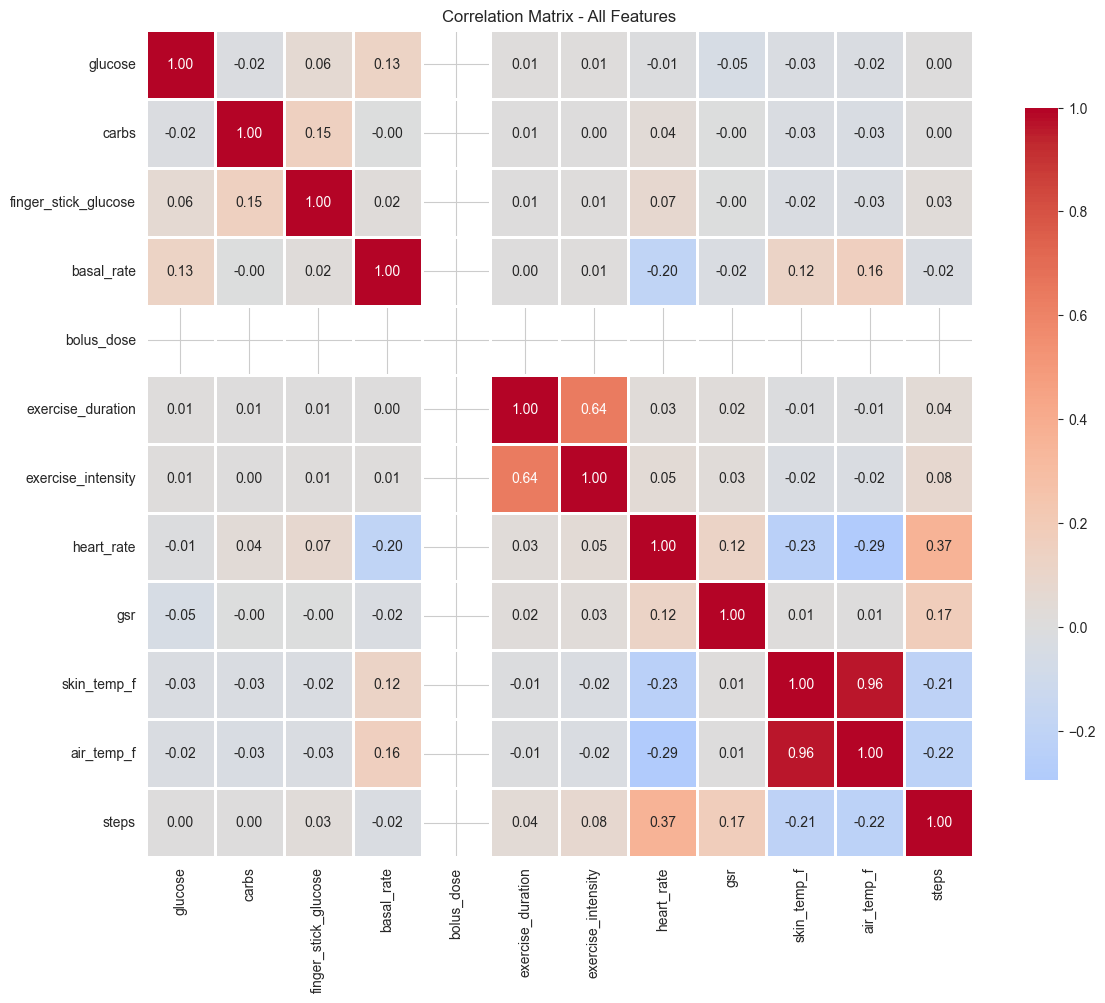

In [11]:
# Select numeric columns for correlation
numeric_cols = ['glucose', 'carbs', 'finger_stick_glucose', 'basal_rate', 'bolus_dose', 
                'exercise_duration', 'exercise_intensity', 'heart_rate', 'gsr', 
                'skin_temp_f', 'air_temp_f', 'steps']

# Compute correlation matrix
corr_matrix = train_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features')
plt.tight_layout()
plt.show()

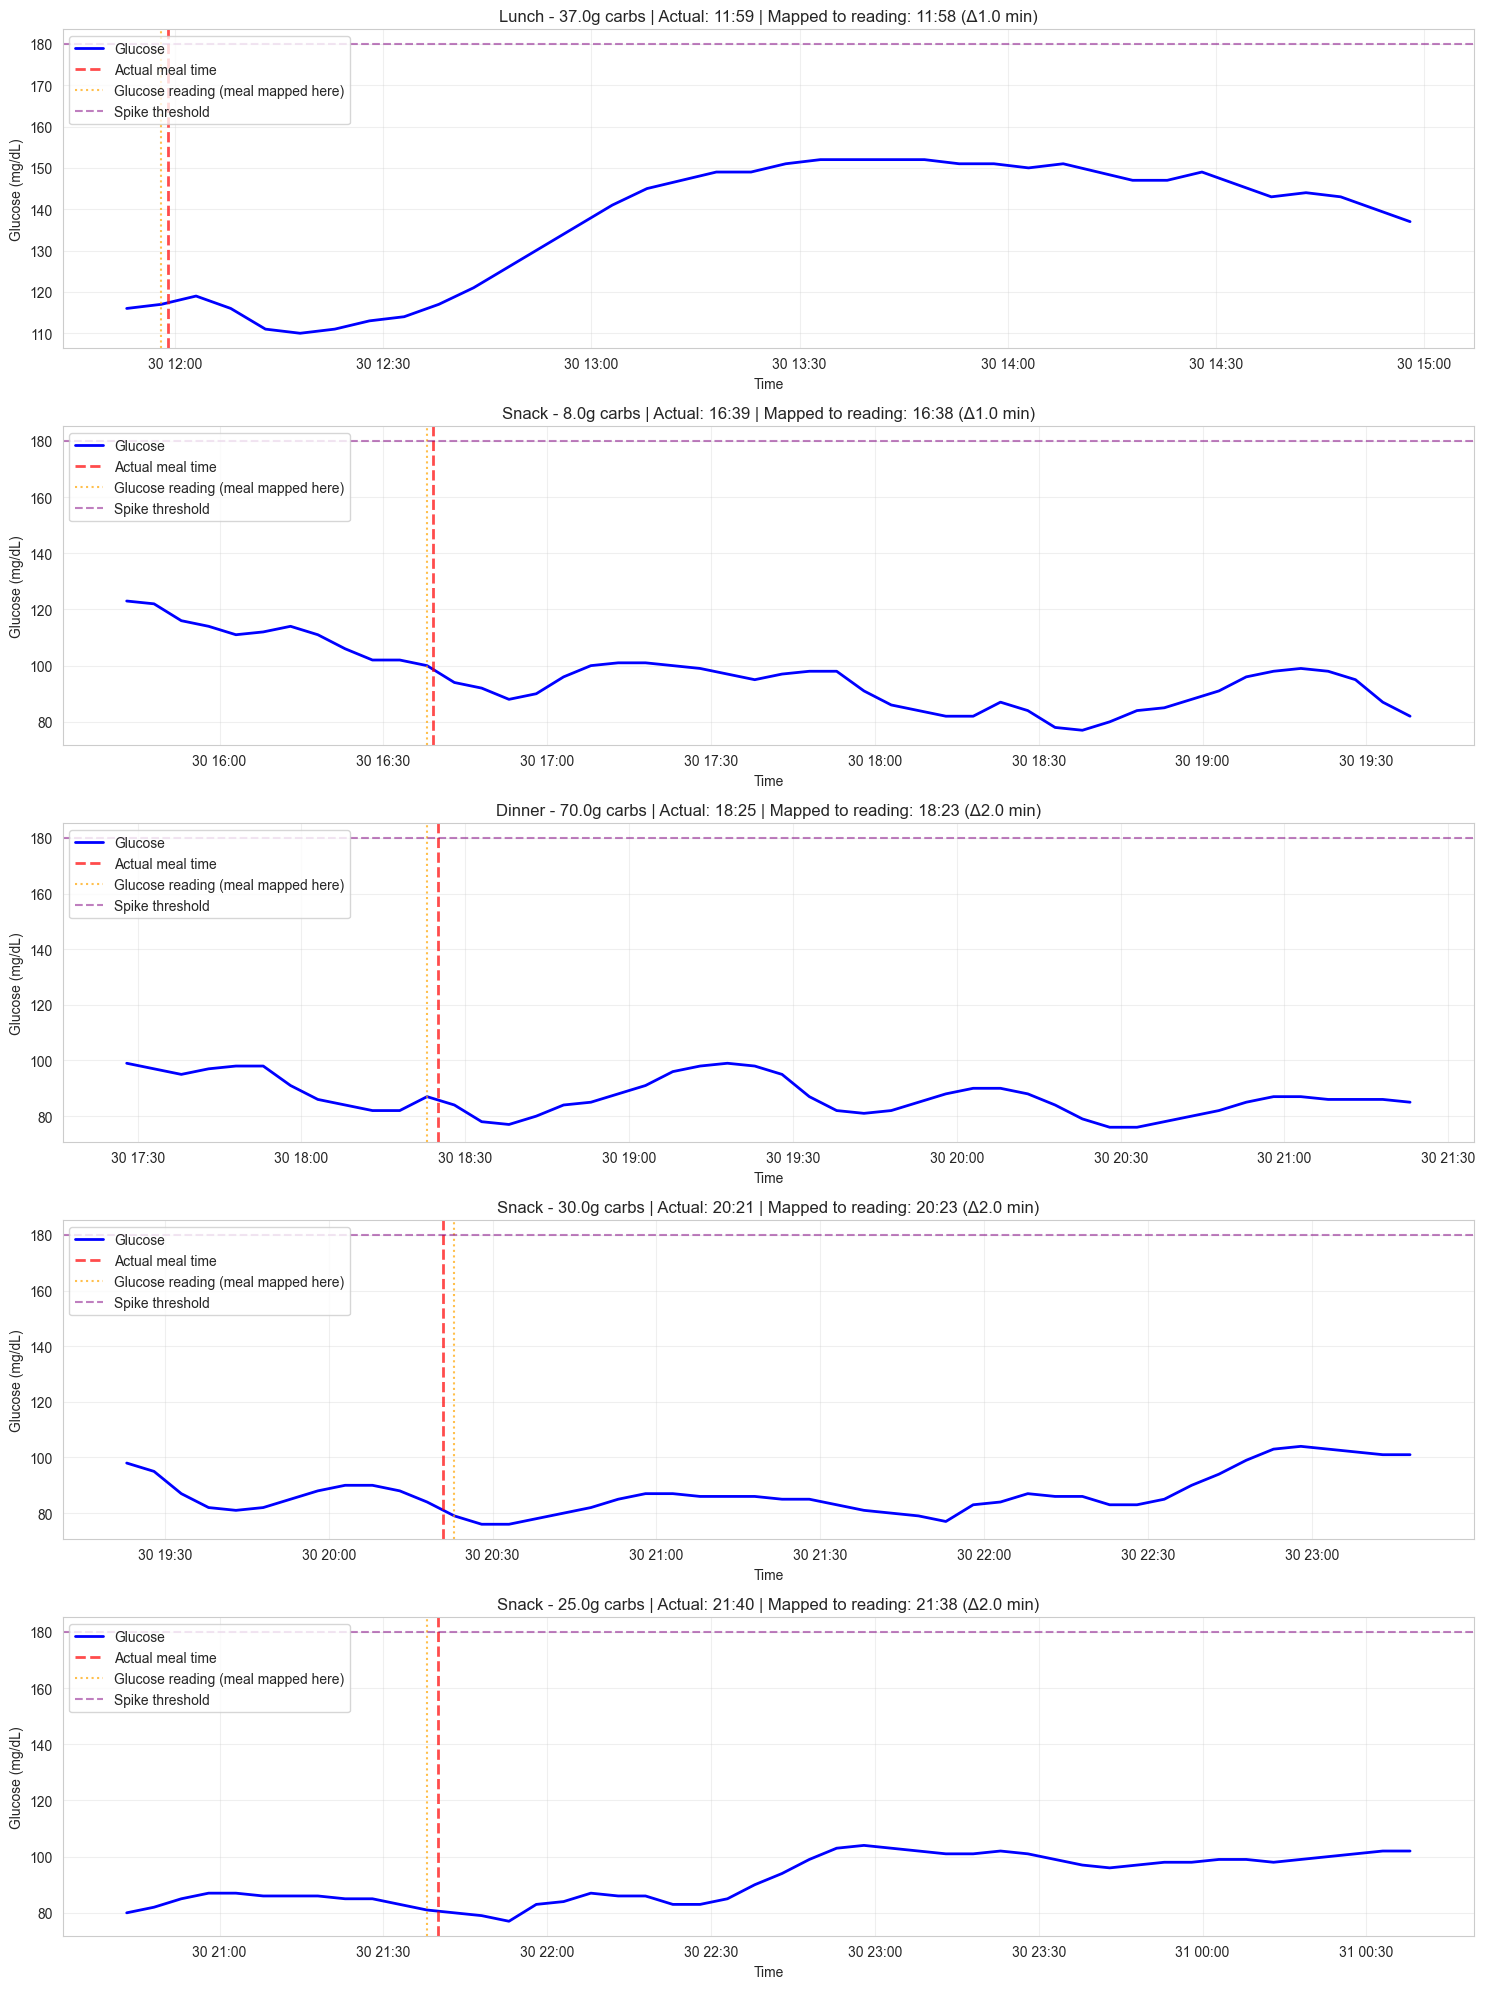


✓ This shows how meals are mapped to the NEAREST glucose reading
✓ The actual meal timestamps are preserved for precise feature engineering


In [17]:
# Glucose response to meals - using actual meal timestamps
patient_id = 588
patient_data = train_df[train_df['patient_id'] == patient_id].copy()

# Get actual meal events (not forward-filled)
meal_events = patient_data[patient_data['carbs'] > 0].head(5)

fig, axes = plt.subplots(len(meal_events), 1, figsize=(15, 4*len(meal_events)))
if len(meal_events) == 1:
    axes = [axes]  # Make it iterable

for idx, (_, meal_row) in enumerate(meal_events.iterrows()):
    # Use ACTUAL meal timestamp, not glucose reading time
    actual_meal_time = meal_row['meal_timestamp']
    glucose_reading_time = meal_row['timestamp']
    carbs = meal_row['carbs']
    meal_type = meal_row['meal_type']
    
    # Get data 1 hour before and 3 hours after ACTUAL meal time
    start_time = actual_meal_time - pd.Timedelta(hours=1)
    end_time = actual_meal_time + pd.Timedelta(hours=3)
    
    meal_window = patient_data[
        (patient_data['timestamp'] >= start_time) & 
        (patient_data['timestamp'] <= end_time)
    ]
    
    if len(meal_window) > 0:
        ax = axes[idx]
        
        # Plot glucose
        ax.plot(meal_window['timestamp'], meal_window['glucose'], 'b-', linewidth=2, label='Glucose')
        
        # Mark actual meal time
        ax.axvline(actual_meal_time, color='red', linestyle='--', linewidth=2, 
                   alpha=0.7, label=f'Actual meal time')
        
        # Mark glucose reading that captured this meal
        ax.axvline(glucose_reading_time, color='orange', linestyle=':', linewidth=1.5,
                   alpha=0.7, label='Glucose reading (meal mapped here)')
        
        ax.axhline(180, color='purple', linestyle='--', alpha=0.5, label='Spike threshold')
        
        time_diff = abs((glucose_reading_time - actual_meal_time).total_seconds() / 60)
        ax.set_title(f'{meal_type} - {carbs}g carbs | Actual: {actual_meal_time.strftime("%H:%M")} | '
                     f'Mapped to reading: {glucose_reading_time.strftime("%H:%M")} (Δ{time_diff:.1f} min)')
        ax.set_xlabel('Time')
        ax.set_ylabel('Glucose (mg/dL)')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ This shows how meals are mapped to the NEAREST glucose reading")
print("✓ The actual meal timestamps are preserved for precise feature engineering")


Spike Statistics by Patient:
            Total Spikes  Spike Rate
patient_id                          
559                 4316   39.977770
563                 2854   23.540086
570                 6047   55.062830
575                 2690   22.669813
588                 4474   35.395570
591                 3482   32.101042


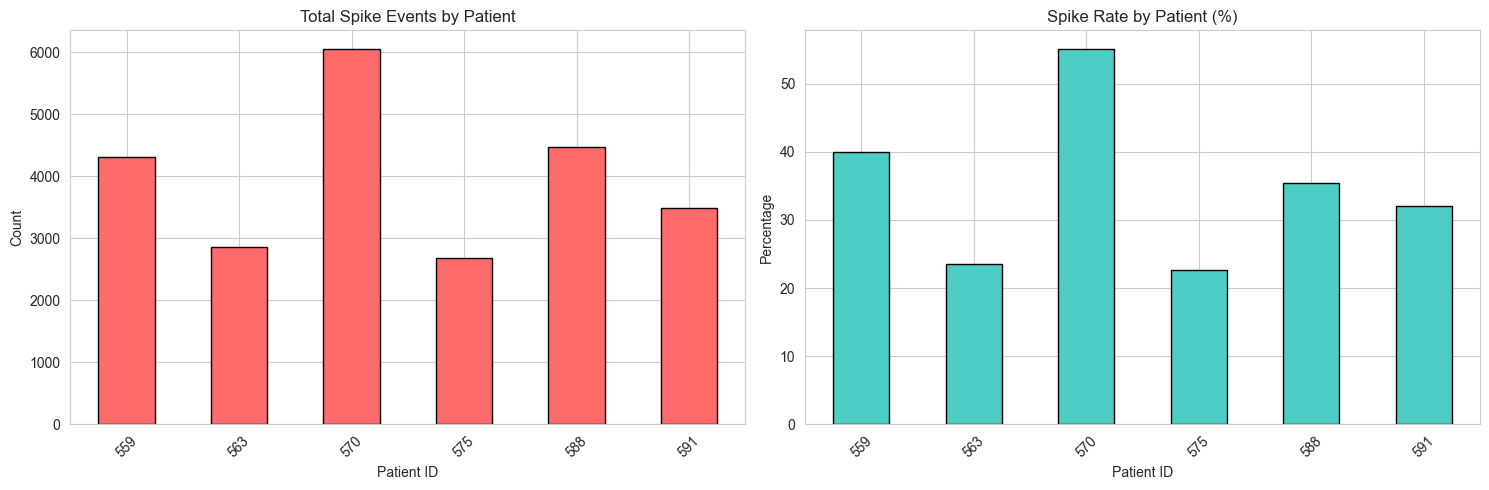


Overall spike rate: 34.5%


In [18]:
# Calculate spike events (glucose > 180 mg/dL)
spike_threshold = 180
train_df['is_spike'] = (train_df['glucose'] > spike_threshold).astype(int)

# Count spikes per patient
spikes_per_patient = train_df.groupby('patient_id')['is_spike'].agg(['sum', 'mean'])
spikes_per_patient.columns = ['Total Spikes', 'Spike Rate']
spikes_per_patient['Spike Rate'] = spikes_per_patient['Spike Rate'] * 100

print("\nSpike Statistics by Patient:")
print(spikes_per_patient)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

spikes_per_patient['Total Spikes'].plot(kind='bar', ax=axes[0], edgecolor='black', color='#FF6B6B')
axes[0].set_title('Total Spike Events by Patient')
axes[0].set_xlabel('Patient ID')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

spikes_per_patient['Spike Rate'].plot(kind='bar', ax=axes[1], edgecolor='black', color='#4ECDC4')
axes[1].set_title('Spike Rate by Patient (%)')
axes[1].set_xlabel('Patient ID')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\nOverall spike rate: {train_df['is_spike'].mean() * 100:.1f}%")

In [19]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal Records: {len(train_df):,}")
print(f"Number of Patients: {train_df['patient_id'].nunique()}")
print(f"Date Range: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Duration: {(train_df['timestamp'].max() - train_df['timestamp'].min()).days} days")

print("\nGlucose Statistics:")
print(f"  Mean: {train_df['glucose'].mean():.1f} mg/dL")
print(f"  Std: {train_df['glucose'].std():.1f} mg/dL")
print(f"  Min: {train_df['glucose'].min():.1f} mg/dL")
print(f"  Max: {train_df['glucose'].max():.1f} mg/dL")
print(f"  Spike rate (>180): {(train_df['glucose'] > 180).mean() * 100:.1f}%")
print(f"  Hypo rate (<70): {(train_df['glucose'] < 70).mean() * 100:.1f}%")

print("\nMeal Statistics (CLEAN EVENT MARKERS):")
meal_events = train_df[train_df['carbs'] > 0]
print(f"  Total meal events: {len(meal_events):,} (no forward-fill duplication!)")
print(f"  Average carbs: {meal_events['carbs'].mean():.1f}g")
print(f"  Meal types: {meal_events['meal_type'].value_counts().to_dict()}")
time_diffs = (meal_events['timestamp'] - meal_events['meal_timestamp']).dt.total_seconds() / 60
print(f"  Avg time diff (meal → glucose reading): {time_diffs.abs().mean():.2f} minutes")

print("\nInsulin Statistics:")
bolus_events = train_df[train_df['bolus_dose'] > 0]
print(f"  Bolus events: {len(bolus_events):,}")
print(f"  Average bolus dose: {bolus_events['bolus_dose'].mean():.1f} units")

print("\nExercise Statistics:")
exercise_events = train_df[train_df['exercise_duration'] > 0]
print(f"  Exercise sessions: {len(exercise_events)}")
if len(exercise_events) > 0:
    print(f"  Average duration: {exercise_events['exercise_duration'].mean():.1f} minutes")
    print(f"  Average intensity: {exercise_events['exercise_intensity'].mean():.1f}/10")

print("\nPhysiological Sensors:")
print(f"  Heart rate readings: {(train_df['heart_rate'] > 0).sum():,}")
print(f"  Average heart rate: {train_df[train_df['heart_rate'] > 0]['heart_rate'].mean():.1f} bpm")
print(f"  Step count readings: {(train_df['steps'] > 0).sum():,}")
print(f"  Average steps (when active): {train_df[train_df['steps'] > 0]['steps'].mean():.1f}")

print("\nEvents:")
print(f"  Hypoglycemic events: {train_df['hypo_event'].sum():.0f}")
print(f"  Stress events: {train_df['stress_event'].sum():.0f}")

print("\n" + "=" * 70)
print("DATA STRUCTURE IMPROVEMENTS")
print("=" * 70)
print(f"✓ Events mapped to NEAREST glucose reading (not forward-filled)")
print(f"✓ Original event timestamps preserved in 6 new columns")
print(f"✓ Clean event markers: carbs > 0 only on actual meal rows")
print(f"✓ Total columns: {len(train_df.columns)} (was 18, now 24)")

DATASET SUMMARY

Total Records: 69,255
Number of Patients: 6
Date Range: 2021-08-30 11:53:00 to 2022-01-17 23:56:00
Duration: 140 days

Glucose Statistics:
  Mean: 160.1 mg/dL
  Std: 60.5 mg/dL
  Min: 40.0 mg/dL
  Max: 400.0 mg/dL
  Spike rate (>180): 34.5%
  Hypo rate (<70): 3.4%

Meal Statistics (CLEAN EVENT MARKERS):
  Total meal events: 1,007 (no forward-fill duplication!)
  Average carbs: 42.7g
  Meal types: {'Snack': 261, 'Dinner': 230, 'Breakfast': 226, 'Lunch': 222, 'HypoCorrection': 68}
  Avg time diff (meal → glucose reading): 1.18 minutes

Insulin Statistics:
  Bolus events: 0
  Average bolus dose: nan units

Exercise Statistics:
  Exercise sessions: 122
  Average duration: 85.3 minutes
  Average intensity: 5.0/10

Physiological Sensors:
  Heart rate readings: 69,255
  Average heart rate: 80.0 bpm
  Step count readings: 17,040
  Average steps (when active): 12.2

Events:
  Hypoglycemic events: 70
  Stress events: 4

DATA STRUCTURE IMPROVEMENTS
✓ Events mapped to NEAREST gluc